## lab 2
## Generation of Random number using pseudo random and chi-sq test

## Objective

1.To learn about what are and how to generate random number in computer

## Theory

Random Number: A sequence of number choosen by chance from a set of numbers.

Condition:  1.Uniformly distributed value over a interval
            2.Impossible to detect based on past and present

Random numbers are foundational across several fields, including:
 * Cybersecurity: Generating cryptographic keys, salts, and nonces.
 * Machine Learning: Shuffling datasets, initializing neural network weights, and stochastic optimization.
 * Scientific Simulation: Running Monte Carlo simulations to model complex physical, economic, or mathematical systems.
### Algorithms for Generating Random Numbers
There are several well-known algorithms used to generate pseudo-random numbers:
 1. Linear Congruential Generator (LCG)
 2. Mersenne Twister
 3. XOR Shift Generator
#### Linear Congruential Generator (LCG)
The LCG is one of the oldest and best-known pseudo-random number generator algorithms. It is highly favored because it is fast and requires very low memory overhead.
The sequence is generated using the following recurrence relation:
Where the parameters are defined as:
 * X_n: The current value in the sequence (with X_0 being the initial seed value).
 * m: The modulus (m > 0). This defines the maximum range and period of the generator.
 * a: The multiplier (0 < a < m).
 * c: The increment (0 \le c < m).
### Why Chi-Square Test?
Once a sequence of pseudo-random numbers is generated, it must be statistically validated to ensure it satisfies the condition of uniform distribution.
The Chi-Square (\chi^2) Goodness-of-Fit Test is used to evaluate whether the generated random numbers are truly uniform or if they exhibit a bias. It compares the observed frequencies of numbers falling into specific intervals against the expected frequencies if the distribution were perfectly uniform.
#### Mathematical Formula:
The Chi-Square test statistic is calculated as:
Where:
 * O_i = Observed frequency of numbers falling into the i-th interval.
 * E_i = Expected frequency of numbers in the i-th interval (under the assumption of a perfect uniform distribution).
 * k = Number of bins / classes (intervals).
If the calculated \chi^2 value is less than or equal to a critical value from the Chi-Square distribution table (at a specific significance level, usually \alpha = 0.05, and degrees of freedom d.f. = k - 1), the hypothesis of uniformity is accepted. Otherwise, it is rejected.




Values of r: [188 113 242 143  88  29 110 155 180 137 170 103 208 181 166 243 172 161
  98  63  72  77 222  75 164 185  26  23 192 229  22 163 156 209 210 239
  56 125  78 251 148 233 138 199 176  21 134  83 140   1  66 159  40 173
 190 171 132  25 250 119 160  69 246   3 124  49 178  79  24 221  46  91
 116  73 106  39 144 117 102 179 108  97  34 255   8  13 158  11 100 121
 218 215 128 165 214  99  92 145 146 175 248  61  14 187  84 169  74 135
 112 213  70  19  76 193   2  95 232 109 126 107  68 217 186  55  96   5
 182 195  60 241 114  15 216 157 238  27  52   9  42 231  80  53  38 115
  44  33 226 191 200 205  94 203  36  57 154 151  64 101 150  35  28  81
  82 111 184 253 206 123  20 105  10  71  48 149   6 211  12 129 194  31
 168  45  62  43   4 153 122 247  32 197 118 131 252 177  50 207 152  93
 174 219 244 201 234 167  16 245 230  51 236 225 162 127 136 141  30 139
 228 249  90  87   0  37  86 227 220  17  18  47 120 189 142  59 212  41
 202   7 240  85 198 147 204  65 130 2

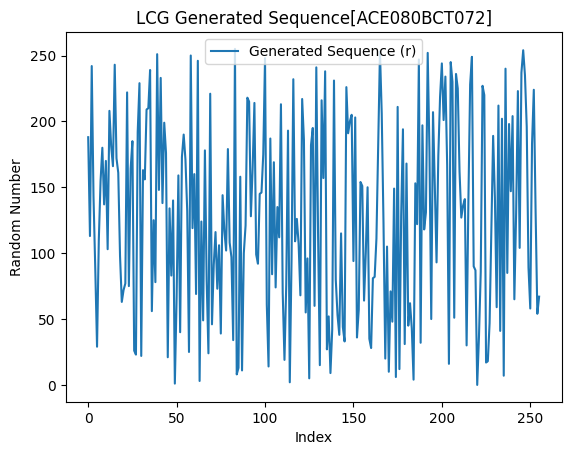

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
import time
# Constants
iterator = 256 # Number of random numbers to generate
a = 29 # Multiplier
b = 37 # Increment
p = 256 # Modulus
n = 8 # Number of bins for Chi-Square test
x02 = 0 # Chi-Square statistic initialization
critical_value = chi2.ppf(1 - 0.05, df = n - 1) # Chi-Square critical value
# Initialize arrays
r = np.ones(shape=(iterator), dtype=int) # Array to store generated random numbers
ei = iterator / n # Expected frequency for each bin
c = np.zeros(shape=(n), dtype=int) # Bin counts
# Initial seed,harek choti random seed dincha
r[0] = int(time.time() * 10000000) % p
# Generate random numbers using LCG
for i in range(0, iterator - 1):
 r[i + 1] = (r[i] * a + b) % p
# Bin the generated numbers and compute frequencies
for i in range(iterator):
    if r[i] <= 31:
        c[0] += 1
    elif r[i] <= 63:
       c[1] += 1
    elif r[i] <= 95:
        c[2] += 1
    elif r[i] <= 127:
        c[3] += 1
    elif r[i] <= 159:
        c[4] += 1
    elif r[i] <= 191:
        c[5] += 1
    elif r[i] <= 223:
        c[6] += 1
    elif r[i] <= 255:
        c[7] += 1
# Compute Chi-Square statistic
for i in range(n):
 x02 += ((c[i] - ei) ** 2) / ei
# Print results
print("Values of r:", r)
print("Values of c (bin frequencies):", c)
print("Value of Chi-Square statistic (x02):", x02)
print("The critical value is", critical_value)
print("Chi square test passed" if x02 <= critical_value else "Chi square test failed")
# Visualize the generated random numbers
plt.figure()
plt.plot(r, label="Generated Sequence (r)")
plt.xlabel("Index")
plt.ylabel("Random Number")
plt.title("LCG Generated Sequence[ACE080BCT072]")
plt.legend()
plt.show()

### Methodology

The seed of the LCG is derived from the system clock at runtime:[x0=(t*10^7)modp] where t is the Unix timestamp obtained via Python's time module and m=256 is the modulus. Multiplying by 10^6 converts the timestamp to microsecond resolution, ensuring sufficient variation between consecutive runs. The modulo operation constrains x0​ to [0,m), consistent with the generator's state space. Since the LCG is fully deterministic, the entire output sequence is uniquely determined by this seed.In short,different execution times produce different seeds and therefore different sequences.

## Discussion and Conclusion

The LCG with parameters a=29,c=37,m=256 satisfies the Hull-Dobell conditions, guaranteeing a full period of 256. Every integer in [0,255] appears exactly once per cycle, producing perfect uniformity. The Chi-Square statistic falls well below the critical value of approx 14.07 (alpha = 0.05,df=7) retaining the null hypothesis of uniformity. However, since N=m=256, this result is trivially guaranteed by construction rather than a meaningful statistical outcome. The time-based seed affects sequence order but not bin frequencies due to the full-period property.

The LCG successfully generates a uniformly distributed pseudo-random sequence, confirmed by the Chi-Square test. Dynamic seeding via the system clock ensures a different sequence on each run. The test is only meaningful when N>>m future evaluation should use larger sample sizes and additional tests to assess independence beyond first-order uniformity.